# Figure 1 Scaling rat connectivity statistics to human volume showed the same results as Kanari et al., 2025

In [1]:
# loading usefull packages and functions

import numpy as np
import h5py
from matplotlib import pyplot as plt
import scipy
import scipy.sparse as sp
import pandas as pd
from pathlib import Path
import pickle

from connalysis.network import classic as nxc
from connalysis.network import topology as nxt
from connalysis import randomization
from connalysis.network import topology
#from conntility import circuit_model
import conntility as conn
#from conntility import ConnectivityMatrix

#### Load all conn matrices to be used in the analysis

In [3]:
def load_conn_mat(conn_mat_path, conn_mat_to_file_name, group_name = None):
    root = conn_mat_path
    if group_name == None:
        conn_mat = conn.ConnectivityMatrix.from_h5(f"{root}{conn_mat_to_file_name}")
        out_put_conn_mat = conn_mat.matrix #.astype(bool).tocsr()
    elif group_name == "instance1":
        conn_mat = conn.ConnectivityMatrix.from_h5(f"{root}{conn_mat_to_file_name}", group_name="instance1")
        out_put_conn_mat = conn_mat.matrix #.astype(bool).tocsr()
    return out_put_conn_mat 

In [7]:
conn_mat_path = "../conn_matrix/" # Complete with your path to connectivity matrices

adj_human_E_to_E = load_conn_mat(conn_mat_path, "Human_pruned_E_to_E_conmat.h5")
adj_human_control_E_to_E = load_conn_mat(conn_mat_path, "humanized_rat_pruned_E_to_E_conmat.h5")
adj_rat_E_to_E = load_conn_mat(conn_mat_path, "Rat_pruned_E_to_E_conmat.h5")

### B) Degree distributions of IN (afferent) and OUT (efferent) connections per node for human (teal), rat (purple) and HC RD model (dashed black line). 
Dashed vertical lines denote mean values of the distributions accordingly.

#### Compute node degree

In [8]:
# HUMAN
nd_human_E_to_E = topology.node_degree(adj_human_E_to_E, direction=('IN', 'OUT'))

# CONTROL
nd_human_control_E_to_E = topology.node_degree(adj_human_control_E_to_E, direction=('IN', 'OUT'))

# RAT
nd_rat_E_to_E = topology.node_degree(adj_rat_E_to_E, direction=('IN', 'OUT'))

#### Plot node degree

In [9]:
def plot_node_degree(nd_human, nd_rat, degree_direction, name, height, nd_control=pd.DataFrame()):
    # nd_human: node degree computation for human con mat
    # nd_rat: node degree computation for human con mat
    # degree_direction: string; IN or OUT
    # name: string with name, preferably name defining matrix type (structural, functional, ...)
    # hight: float; y axes upper value
    # nd_control: node degree computation for human control. It doesn't exist for functional case.

    fig, ax0 = plt.subplots(figsize=(8, 6))
    ax0.set_title('%s %s: human %s, rat %s' %(name, degree_direction, np.mean(nd_human), np.mean(nd_rat)))
    if degree_direction == "IN":
        if not nd_control.empty:
            ax0.hist(nd_human.IN, 30, density=False, alpha=0.5, color='teal', label='human')
            ax0.hist(nd_rat.IN, 30, density=False, alpha=0.5, color='blueviolet', label='rat')
            ax0.hist(nd_control.IN, 30, density=False, histtype='step', fill=False, linestyle='dashed', linewidth=2, color='black', label='HC_RD')
            ax0.axvline(np.mean(nd_human.IN), color='teal', linestyle='dashed', linewidth=2)
            ax0.axvline(np.mean(nd_rat.IN), color='blueviolet', linestyle='dashed', linewidth=2)
        else:
            ax0.hist(nd_human.IN, 30, density=False, alpha=0.5, color='teal', label='human')
            ax0.hist(nd_rat.IN, 30, density=False, alpha=0.5, color='blueviolet', label='rat')
            ax0.axvline(np.mean(nd_human.IN), color='teal', linestyle='dashed', linewidth=2)
            ax0.axvline(np.mean(nd_rat.IN), color='blueviolet', linestyle='dashed', linewidth=2)
    elif degree_direction == "OUT":
       if not nd_control.empty:
            ax0.hist(nd_human.OUT, 30, density=False, alpha=0.5, color='teal', label='human')
            ax0.hist(nd_rat.OUT, 30, density=False, alpha=0.5, color='blueviolet', label='rat')
            ax0.hist(nd_control.OUT, 30, density=False, histtype='step', fill=False, linestyle='dashed', linewidth=2, color='black', label='HC_RD')
            ax0.axvline(np.mean(nd_human.OUT), color='teal', linestyle='dashed', linewidth=2)
            ax0.axvline(np.mean(nd_rat.OUT), color='blueviolet', linestyle='dashed', linewidth=2)
       else:
            ax0.hist(nd_human.OUT, 30, density=False, alpha=0.5, color='teal', label='human')
            ax0.hist(nd_rat.OUT, 30, density=False, alpha=0.5, color='blueviolet', label='rat')
            ax0.axvline(np.mean(nd_human.OUT), color='teal', linestyle='dashed', linewidth=2)
            ax0.axvline(np.mean(nd_rat.OUT), color='blueviolet', linestyle='dashed', linewidth=2)
    ax0.tick_params(axis='x', labelsize=15)
    ax0.tick_params(axis='y', labelsize=15)
    ax0.set_ylim(0, height)
    ax0.set_xlabel('Node degree', fontsize=15)
    ax0.set_ylabel('Counts', fontsize=15)
    ax0.spines[['right', 'top']].set_visible(False)
    #plt.savefig('%s_degree_%s_matrices.svg' %(degree_direction, name), transparent=True, bbox_inches='tight')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

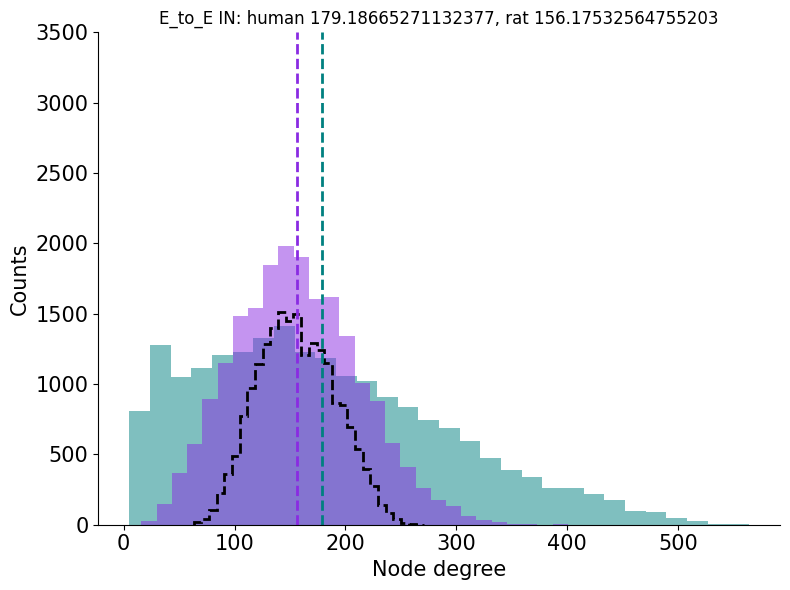

In [10]:
plot_node_degree(nd_human_E_to_E, nd_rat_E_to_E, "IN", "E_to_E", 3500, nd_human_control_E_to_E)

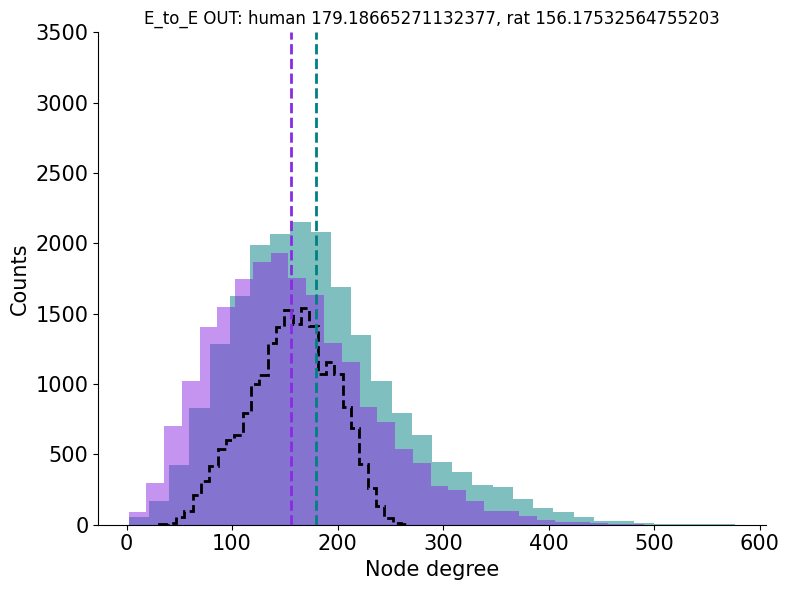

In [11]:
plot_node_degree(nd_human_E_to_E, nd_rat_E_to_E, "OUT", "E_to_E", 3500, nd_human_control_E_to_E)

### C) Skew analysis for the degree distributions in B. 

In [12]:
# IN
sk_human_E_to_E_in = scipy.stats.skew(nd_human_E_to_E.IN)
sk_control_E_to_E_in = scipy.stats.skew(nd_human_control_E_to_E.IN)
sk_rat_E_to_E_in = scipy.stats.skew(nd_rat_E_to_E.IN)

In [13]:
# OUT
sk_human_E_to_E_out = scipy.stats.skew(nd_human_E_to_E.OUT)
sk_control_E_to_E_out = scipy.stats.skew(nd_human_control_E_to_E.OUT)
sk_rat_E_to_E_out = scipy.stats.skew(nd_rat_E_to_E.OUT)

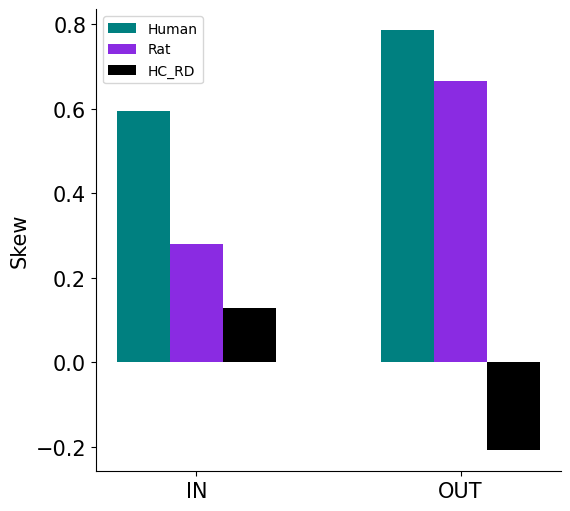

In [14]:
direction = ("IN", "OUT")

sk_human = [sk_human_E_to_E_in, sk_human_E_to_E_out]
sk_rat = [sk_rat_E_to_E_in, sk_rat_E_to_E_out]
sk_control = [sk_control_E_to_E_in, sk_control_E_to_E_out ]

dis = [0, 5]

barwidth = 2
br1 = [x - barwidth/2 for x in dis] 
br2 = [x for x in dis] 
br3 = [x + barwidth/2 for x in dis] 

plt.figure(figsize=(6, 6))
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.bar(br1, sk_human, color='teal', width=1, label='Human')
plt.bar(br2, sk_rat, color='blueviolet', width=1, label='Rat')
plt.bar(br3, sk_control, color='black', width=1, label='HC_RD')
plt.ylabel('Skew', fontsize=15)
plt.xticks(dis, direction, fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=10)

### D) Simplex counts in logarithmic scale for human (teal), rat (purple) and HC_RD (black).

In [15]:
root_path = "simplex_counts/"

sc_human_EtoE = pd.read_pickle(f"{root_path}human_EtoE_sc.pkl")
sc_rat_EtoE = pd.read_pickle(f"{root_path}rat_EtoE_sc.pkl")
sc_control_EtoE = pd.read_pickle(f"{root_path}hc_rd_EtoE_sc.pkl")

In [16]:
sc_control_EtoE['EtoE']

dim
0      20064
1    3129285
2    5031729
3     110345
4         41
Name: simplex_count, dtype: int64

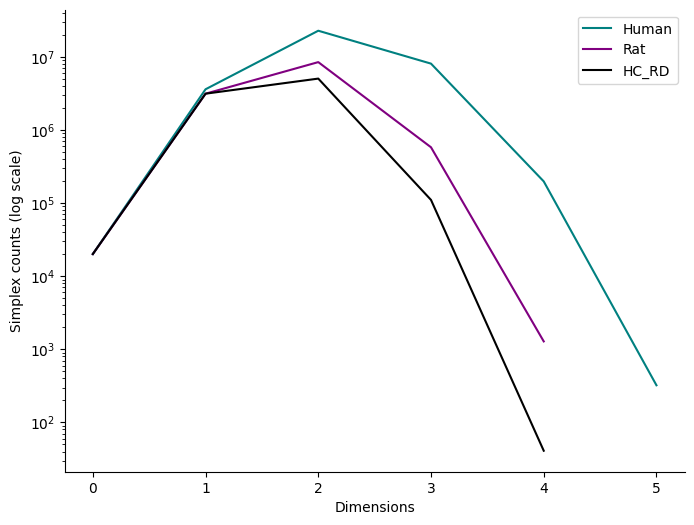

In [17]:
plt.figure(figsize=(8, 6))
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.plot(sc_human_EtoE['EtoE'], color='teal', label='Human')
plt.plot(sc_rat_EtoE['EtoE'], color='purple', label='Rat')
plt.plot(sc_control_EtoE['EtoE'], color='black', label='HC_RD')
plt.yscale('log')
plt.ylabel('Simplex counts (log scale)')
plt.xlabel('Dimensions')
plt.legend()
plt.show()